# Customer / Sales Data Analysis using Python
**Key Skills:** Python, Pandas, NumPy, Matplotlib, Seaborn, Statistics

This notebook analyzes a retail sales dataset (3,000 transactions, 2024-2025) to uncover revenue trends, customer behaviour, and feature correlations. It covers data loading & cleaning, descriptive statistics, groupby aggregations, visualizations (line/bar/histogram/heatmap), and a written summary of insights.

**Dataset:** `data/sales_data.csv` — synthetic but realistic retail transactions (order date, customer demographics, region, product category, pricing, discounts, payment method, satisfaction rating).

## 1. Imports & Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

## 2. Load & Inspect the Data

In [2]:
df = pd.read_csv("../data/sales_data.csv", parse_dates=["OrderDate"])
print("Shape:", df.shape)
df.head()

Shape: (3000, 15)


    OrderID  OrderDate  ... PaymentMethod  CustomerSatisfaction
0  ORD01221 2024-01-01  ...    Debit Card                   5.0
1  ORD01158 2024-01-01  ...   Net Banking                   5.0
2  ORD01837 2024-01-01  ...           UPI                   3.0
3  ORD02880 2024-01-01  ...    Debit Card                   5.0
4  ORD00998 2024-01-02  ...   Net Banking                   3.0

[5 rows x 15 columns]

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   OrderID               3000 non-null   str           
 1   OrderDate             3000 non-null   datetime64[us]
 2   CustomerID            3000 non-null   str           
 3   Age                   3000 non-null   int64         
 4   Gender                3000 non-null   str           
 5   Region                3000 non-null   str           
 6   City                  3000 non-null   str           
 7   ProductCategory       3000 non-null   str           
 8   Product               3000 non-null   str           
 9   Quantity              3000 non-null   int64         
 10  UnitPrice             3000 non-null   float64       
 11  DiscountPercent       3000 non-null   int64         
 12  TotalSales            3000 non-null   float64       
 13  PaymentMethod         3000 no

In [4]:
df.isna().sum()

OrderID                  0
OrderDate                0
CustomerID               0
Age                      0
Gender                   0
Region                   0
City                     0
ProductCategory          0
Product                  0
Quantity                 0
UnitPrice                0
DiscountPercent          0
TotalSales               0
PaymentMethod            0
CustomerSatisfaction    60
dtype: int64

**Observation:** the dataset has 3,000 rows and 15 columns. `CustomerSatisfaction` has a small number of missing values (~2%), which we'll impute below.

## 3. Data Cleaning

In [5]:
df["CustomerSatisfaction"] = df["CustomerSatisfaction"].fillna(df["CustomerSatisfaction"].median())
df["OrderMonth"] = df["OrderDate"].dt.to_period("M").astype(str)
df["OrderQuarter"] = df["OrderDate"].dt.to_period("Q").astype(str)
df.isna().sum().sum()  # confirm no missing values remain

np.int64(0)

## 4. Descriptive Statistics

In [6]:
numeric_cols = ["Age", "Quantity", "UnitPrice", "DiscountPercent", "TotalSales", "CustomerSatisfaction"]
desc_stats = df[numeric_cols].describe().round(2)
desc_stats

           Age  Quantity  ...  TotalSales  CustomerSatisfaction
count  3000.00   3000.00  ...     3000.00               3000.00
mean     34.71      2.06  ...    16347.98                  3.89
std      10.40      1.20  ...    34628.55                  0.86
min      18.00      1.00  ...       82.98                  1.00
25%      27.00      1.00  ...     1588.30                  3.00
50%      34.00      2.00  ...     3978.18                  4.00
75%      42.00      3.00  ...    11660.93                  5.00
max      68.00      5.00  ...   303171.60                  5.00

[8 rows x 6 columns]

In [7]:
total_revenue = df["TotalSales"].sum()
total_orders = len(df)
unique_customers = df["CustomerID"].nunique()
avg_order_value = df["TotalSales"].mean()
repeat_customers = (df["CustomerID"].value_counts() > 1).sum()
repeat_rate = repeat_customers / unique_customers * 100

print(f"Total Revenue:        Rs.{total_revenue:,.2f}")
print(f"Total Orders:         {total_orders:,}")
print(f"Unique Customers:     {unique_customers:,}")
print(f"Avg Order Value:      Rs.{avg_order_value:,.2f}")
print(f"Repeat Customers:     {repeat_customers:,} ({repeat_rate:.1f}%)")

Total Revenue:        Rs.49,043,936.07
Total Orders:         3,000
Unique Customers:     1,017
Avg Order Value:      Rs.16,347.98
Repeat Customers:     696 (68.4%)


## 5. Sales Trends Over Time

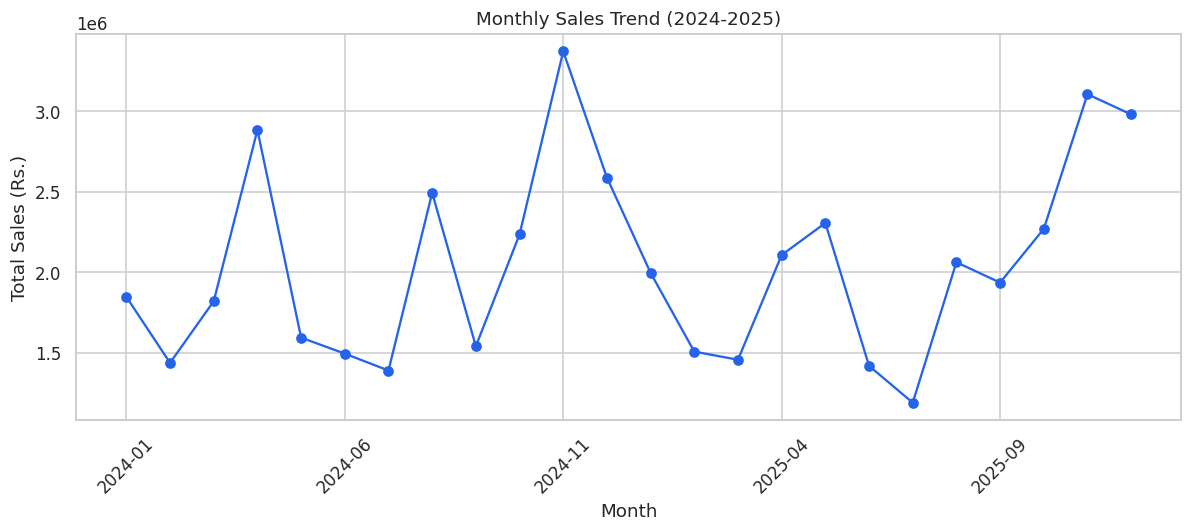

In [8]:
monthly_sales = df.groupby("OrderMonth")["TotalSales"].sum().sort_index()

plt.figure(figsize=(11, 5))
monthly_sales.plot(kind="line", marker="o", color="#2563eb")
plt.title("Monthly Sales Trend (2024-2025)")
plt.xlabel("Month"); plt.ylabel("Total Sales (Rs.)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** revenue spikes sharply in **Oct–Dec**, consistent with the festive shopping season (Diwali sales, year-end promotions).

## 6. Revenue by Product Category & Region

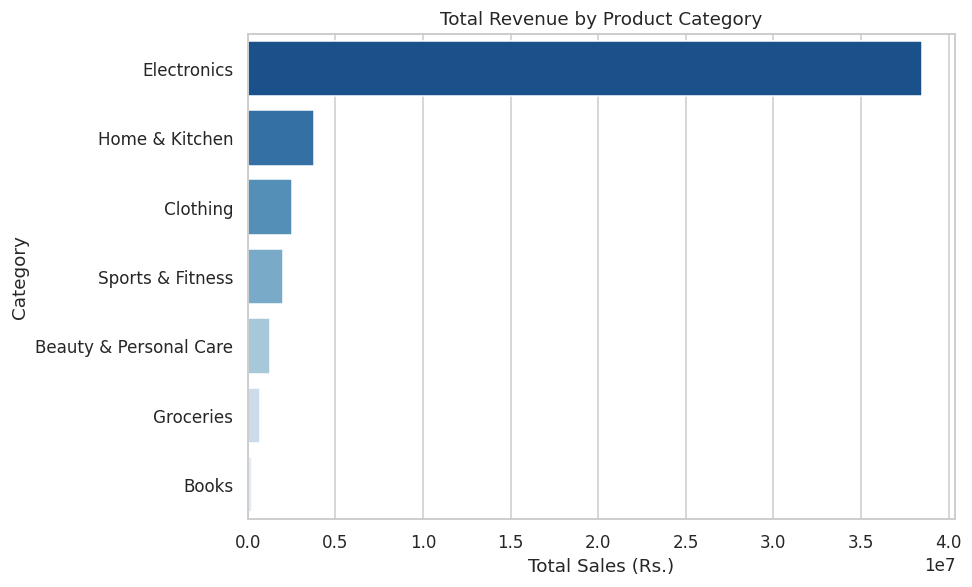

In [9]:
category_sales = df.groupby("ProductCategory")["TotalSales"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5.5))
sns.barplot(x=category_sales.values, y=category_sales.index, hue=category_sales.index, palette="Blues_r", legend=False)
plt.title("Total Revenue by Product Category")
plt.xlabel("Total Sales (Rs.)"); plt.ylabel("Category")
plt.tight_layout()
plt.show()

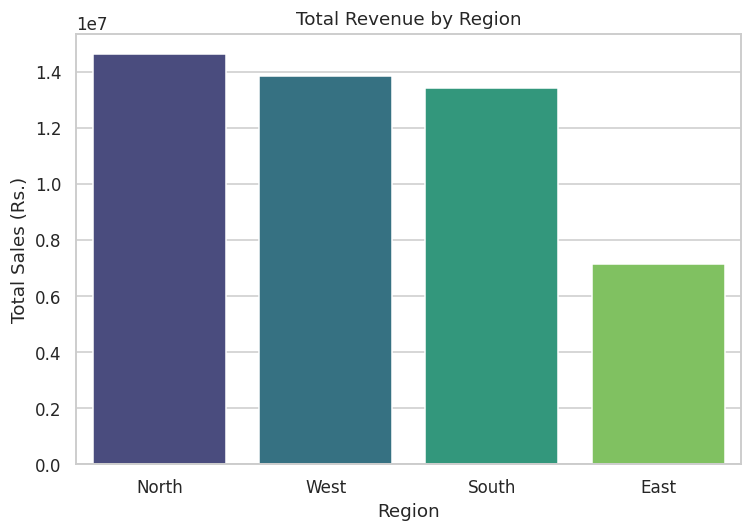

In [10]:
region_sales = df.groupby("Region")["TotalSales"].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=region_sales.index, y=region_sales.values, hue=region_sales.index, palette="viridis", legend=False)
plt.title("Total Revenue by Region")
plt.xlabel("Region"); plt.ylabel("Total Sales (Rs.)")
plt.tight_layout()
plt.show()

## 7. Distributions: Order Value & Customer Age

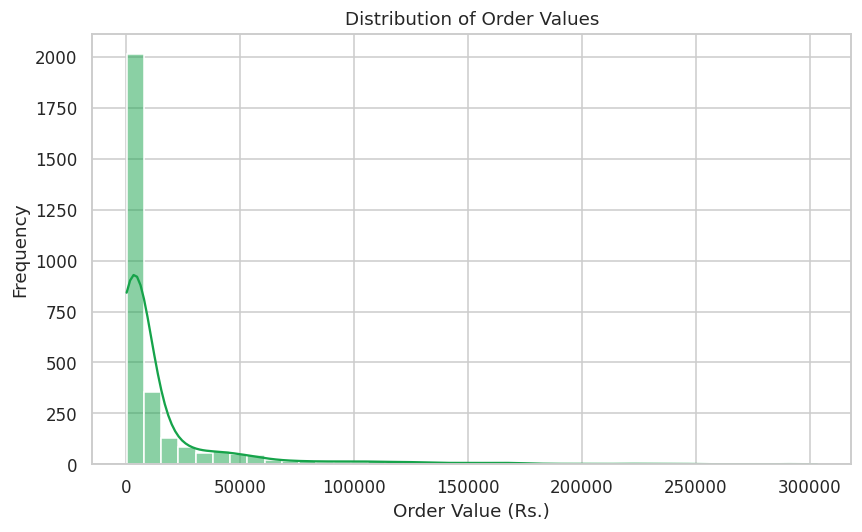

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df["TotalSales"], bins=40, kde=True, color="#16a34a")
plt.title("Distribution of Order Values")
plt.xlabel("Order Value (Rs.)"); plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

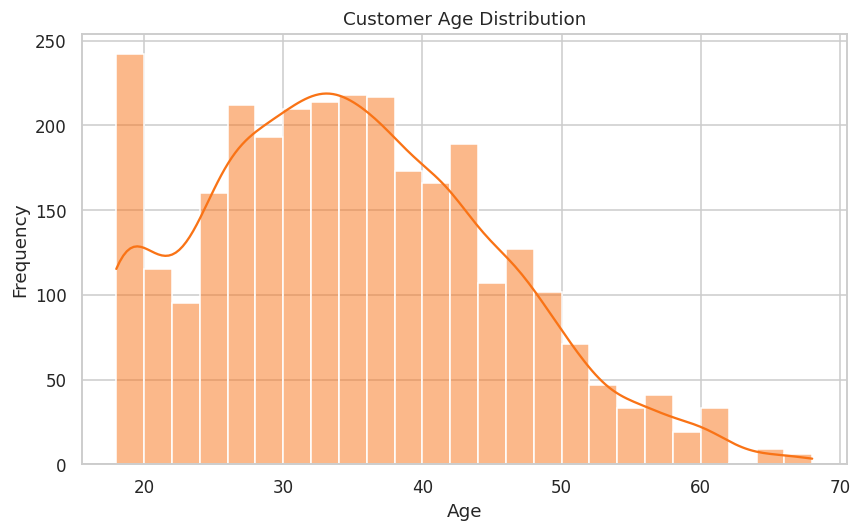

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=25, kde=True, color="#f97316")
plt.title("Customer Age Distribution")
plt.xlabel("Age"); plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 8. Payment Method Preferences

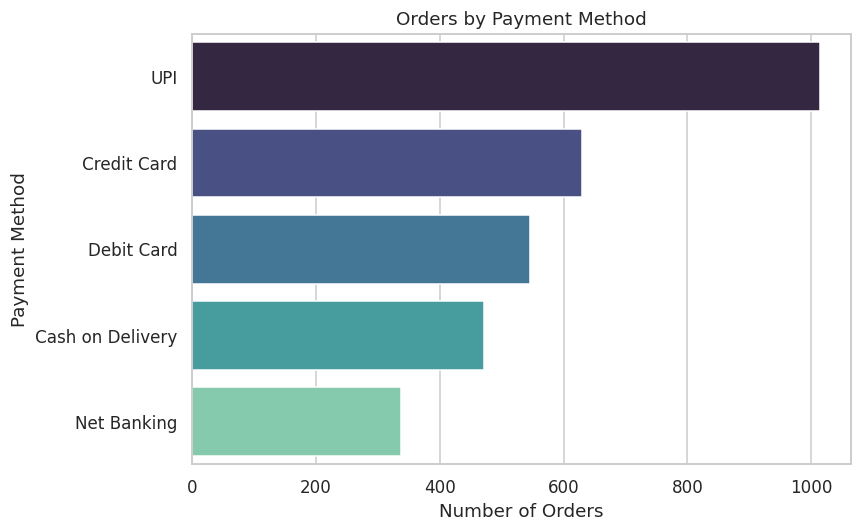

In [13]:
payment_counts = df["PaymentMethod"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=payment_counts.values, y=payment_counts.index, hue=payment_counts.index, palette="mako", legend=False)
plt.title("Orders by Payment Method")
plt.xlabel("Number of Orders"); plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()

## 9. Correlation Analysis

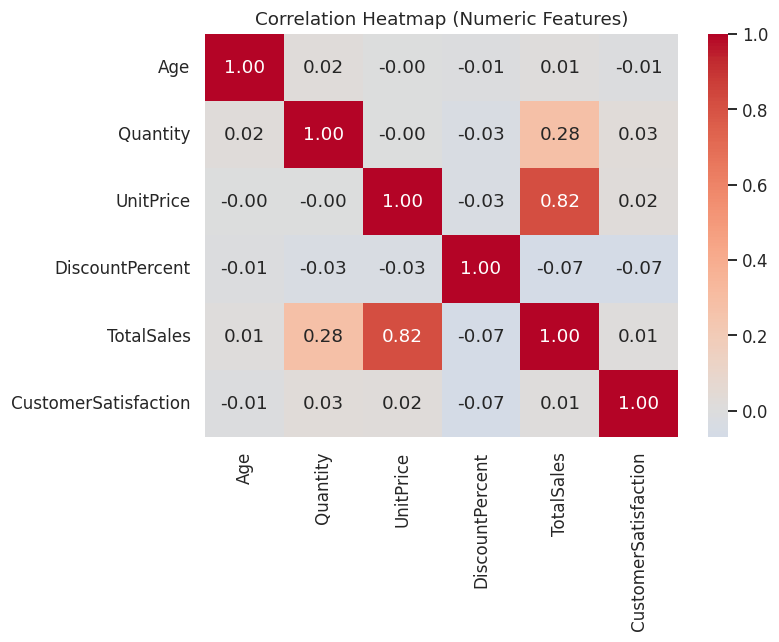

In [14]:
corr_matrix = df[numeric_cols].corr().round(2)

plt.figure(figsize=(7.5, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

**Insight:** `UnitPrice` correlates strongly with `TotalSales` (0.82) — high-ticket items (Electronics) drive revenue more than order quantity does (0.28 correlation). `DiscountPercent` shows a weak negative correlation with `CustomerSatisfaction`, suggesting heavier discounting doesn't necessarily buy goodwill in this dataset — satisfaction is driven more by other factors.

## 10. Key Findings Summary

In [15]:
top_category = category_sales.idxmax()
top_region = region_sales.idxmax()
best_month = monthly_sales.idxmax()

print(f"Top Category : {top_category} (Rs.{category_sales.max():,.0f})")
print(f"Top Region   : {top_region} (Rs.{region_sales.max():,.0f})")
print(f"Best Month   : {best_month} (Rs.{monthly_sales.max():,.0f})")
print(f"Most Used Payment Method : {payment_counts.idxmax()}")

Top Category : Electronics (Rs.38,455,524)
Top Region   : North (Rs.14,622,988)
Best Month   : 2024-11 (Rs.3,371,411)
Most Used Payment Method : UPI


### Conclusions
1. **Electronics** is the dominant revenue driver, contributing the majority of total sales despite being a mid-share category by order count — a small number of high-value transactions has outsized impact.
2. **Festive season (Oct–Dec)** produces a clear, repeatable spike in revenue — a strong candidate for inventory planning and targeted promotions.
3. **North and West regions** lead in revenue, suggesting concentrated marketing spend there could have higher ROI, while **East** is under-penetrated and a growth opportunity.
4. **UPI** is the most-used payment method, reflecting broader digital payment adoption trends in the Indian retail market.
5. Discounting shows **no strong positive correlation with satisfaction**, implying promotions should be evaluated on revenue/margin impact rather than assumed customer-experience benefits.

*(Full numerical summary and methodology in `../summary_report.md`)*